**Load and prepare**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load
rfm = pd.read_csv("../output/rfm_segments.csv")
rfm["Churn"] = rfm["Segment"].apply(lambda x: 1 if x in ["At Risk", "Lost"] else 0)

X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Churn rate: {y.mean()*100:.1f}%")

Train: 3470 | Test: 868
Churn rate: 29.8%


**Train default XGBoost**

In [2]:
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print("XGBoost — Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

XGBoost — Classification Report:
              precision    recall  f1-score   support

      Active       0.98      0.97      0.98       610
     Churned       0.93      0.96      0.94       258

    accuracy                           0.97       868
   macro avg       0.95      0.96      0.96       868
weighted avg       0.97      0.97      0.97       868

ROC-AUC: 0.9951


**Feature importance**

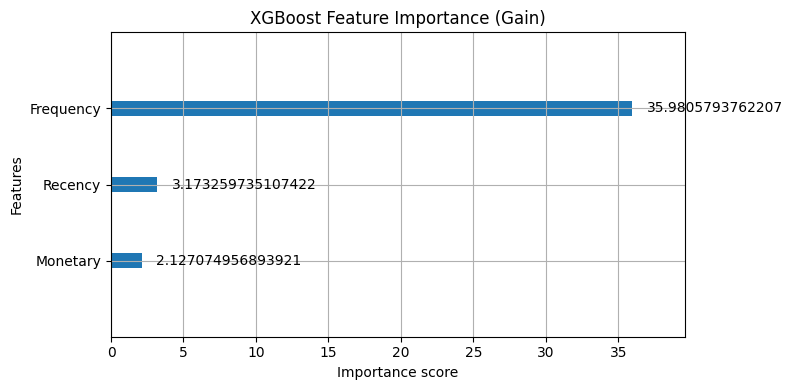

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_importance(xgb, ax=ax, importance_type="gain",
                title="XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.savefig("../output/xgb_feature_importance.png", dpi=150)
plt.show()

**Tune XGBoost with GridSearchCV**

In [4]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.1, 0.3],
    "subsample": [0.8, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)
gs.fit(X_train, y_train)

print(f"Best params: {gs.best_params_}")
print(f"Best CV AUC: {gs.best_score_:.4f}")

best_xgb = gs.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

print("\nTuned XGBoost — Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=["Active", "Churned"]))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1.0}
Best CV AUC: 0.9953

Tuned XGBoost — Classification Report:
              precision    recall  f1-score   support

      Active       1.00      0.96      0.98       610
     Churned       0.91      1.00      0.95       258

    accuracy                           0.97       868
   macro avg       0.95      0.98      0.97       868
weighted avg       0.97      0.97      0.97       868

Test ROC-AUC: 0.9946


**Final model comparison**

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression":        LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree (tuned)":      DecisionTreeClassifier(max_depth=5, criterion="entropy",
                                                          min_samples_leaf=10, random_state=42),
    "Random Forest":              RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost (default)":         XGBClassifier(n_estimators=100, random_state=42,
                                                eval_metric="logloss", verbosity=0),
    "XGBoost (tuned)":           best_xgb,
}

print(f"{'Model':<30} {'Mean AUC':>10} {'Std':>8}")
print("-" * 52)
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="roc_auc")
    print(f"{name:<30} {scores.mean():>10.4f} {scores.std():>8.4f}")

Model                            Mean AUC      Std
----------------------------------------------------
Logistic Regression                0.9813   0.0034
Decision Tree (tuned)              0.9913   0.0049
Random Forest                      0.9945   0.0015
XGBoost (default)                  0.9947   0.0012
XGBoost (tuned)                    0.9952   0.0013


**ROC curve for all models**

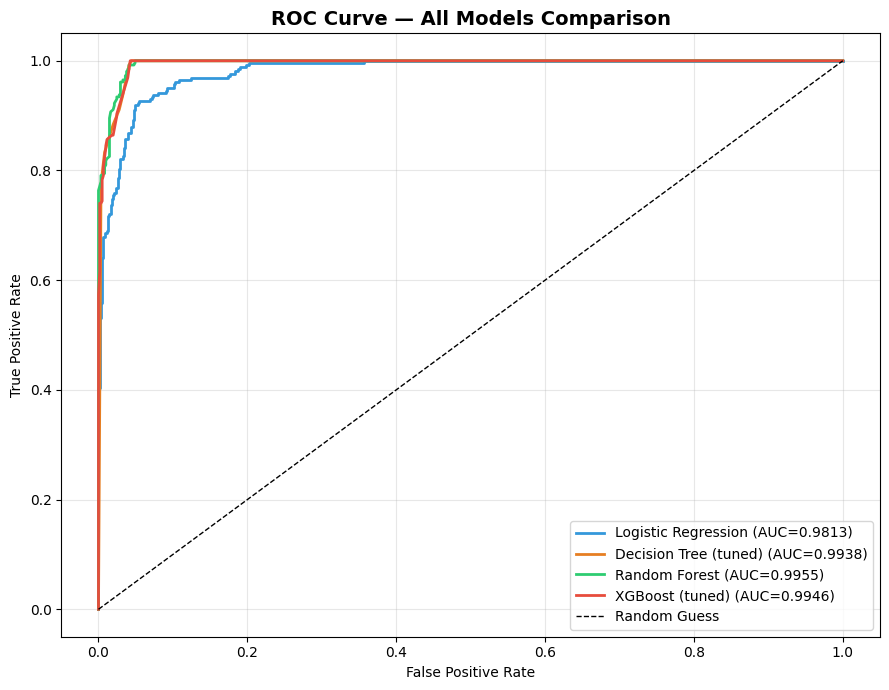

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

model_configs = [
    ("Logistic Regression", LogisticRegression(random_state=42, max_iter=1000), X_scaled[X_test.index], "#3498db"),
    ("Decision Tree (tuned)", DecisionTreeClassifier(max_depth=5, criterion="entropy", min_samples_leaf=10, random_state=42), X_test, "#e67e22"),
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42), X_test, "#2ecc71"),
    ("XGBoost (tuned)", best_xgb, X_test, "#e74c3c"),
]

for name, model, X_t, color in model_configs:
    if name == "Logistic Regression":
        scaler2 = StandardScaler()
        X_tr_s = scaler2.fit_transform(X_train)
        model.fit(X_tr_s, y_train)
        prob = model.predict_proba(X_t)[:, 1]
    else:
        model.fit(X_train, y_train)
        prob = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2, color=color, label=f"{name} (AUC={auc:.4f})")

ax.plot([0,1],[0,1], "k--", linewidth=1, label="Random Guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — All Models Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../output/all_models_roc.png", dpi=150)
plt.show()